In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from sklearn.datasets import load_digits
from sklearn.metrics import mean_squared_error


/Users/akshayd/miniconda3/envs/cs6402/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
## Data Preprocessing

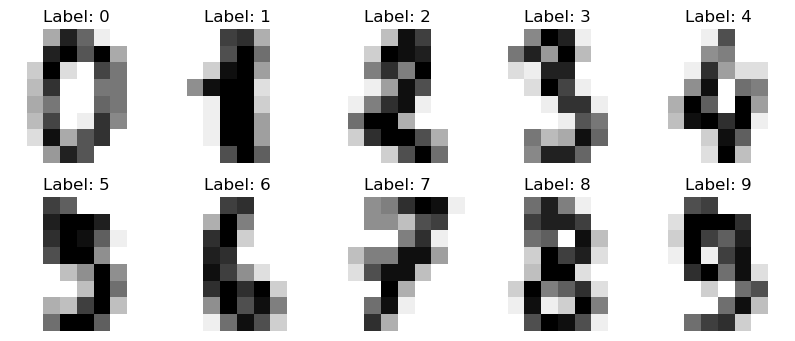

In [3]:
digits = load_digits()
x = digits.data
y = digits.target

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(x[i].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")
plt.savefig("00_raw_digits.png", dpi=150)

Class distribution in sample:
Digit 0: 2 images
Digit 1: 1 images
Digit 2: 2 images
Digit 3: 2 images
Digit 4: 3 images
Digit 5: 4 images
Digit 6: 2 images
Digit 7: 1 images
Digit 8: 3 images
Digit 9: 5 images
Dataset: 25 images, 64 pixels each
Probability of Pixel being on: 0.37375


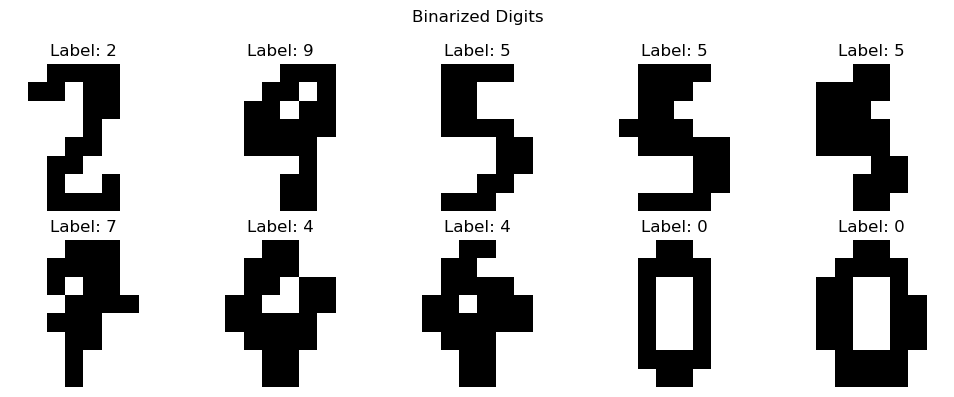

In [4]:
rng = np.random.default_rng(42)
threshold = 4
x_thresh = (x > threshold).astype(np.float64)


N_SAMPLE = 25
indices = rng.choice(len(x_thresh), size=N_SAMPLE, replace=False)
 
X = x_thresh[indices]
y_sampled = y[indices]

# Class distribution counts
unique, counts = np.unique(y_sampled, return_counts=True)
print("Class distribution in sample:")
for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count} images")
 
N, D = X.shape
print(f"Dataset: {N} images, {D} pixels each")
print(f"Probability of Pixel being on: {X.mean()}")

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"Label: {y_sampled[i]}")
    ax.axis("off")
fig.suptitle("Binarized Digits")
plt.tight_layout()
plt.savefig("02_sample_digits.png", dpi=150)
plt.show()

In [5]:
K = 10
N_model = N

def generate_model(alpha, beta, var_names, alpha_value):
    with pm.Model() as mixture_model:
        w = pm.Dirichlet("w", a=np.ones(K) * alpha_value, shape=K)
        theta = pm.Beta("theta", alpha=alpha, beta=beta, shape=(K, D))
    
        components = [
            pm.Bernoulli.dist(p=theta[k], shape=D)
            for k in range(K)
        ]
     
        likelihood = pm.Mixture(
            "obs",
            w=w,
            comp_dists=components,
            observed=X,
            shape=(N_model, D),
        )
        trace = pm.sample(
            draws=2000,
            tune=1000,
            target_accept=0.98,
            random_seed=rng,
            idata_kwargs=dict(log_likelihood=True),
        )
        ppc = pm.sample_posterior_predictive(trace, random_seed=rng)
    return trace, az.summary(trace, var_names=var_names, hdi_prob=0.95), ppc

In [6]:
def trace_plots(trace, var_names, trace_name, coords=None):
    axes = az.plot_trace(trace, var_names=var_names, coords=coords)

    axes[0, 0].set_xlabel("Class Probability")
    axes[0, 0].set_ylabel("Frequency")
    axes[0, 1].set_xlabel("Sample Number")
    axes[0, 1].set_ylabel("Class Probability")
    plt.tight_layout()
    plt.savefig(trace_name, dpi=150)
    plt.show()


In [7]:
## Experimentation w/ Different parameters
trace_1, summary_1, ppc_1 = generate_model(1, 2, ["w"], 0.5)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, theta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 142 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [obs]


Output()

In [8]:
print(summary_1[["mean", "sd", "ess_bulk", "r_hat"]].to_latex(escape=True, float_format="%.3f"))

\begin{tabular}{lrrrr}
\toprule
 & mean & sd & ess\_bulk & r\_hat \\
\midrule
w[0] & 0.003 & 0.005 & 7959.000 & 1.000 \\
w[1] & 0.003 & 0.005 & 7120.000 & 1.000 \\
w[2] & 0.245 & 0.419 & 7.000 & 1.530 \\
w[3] & 0.003 & 0.005 & 8316.000 & 1.000 \\
w[4] & 0.003 & 0.005 & 8216.000 & 1.000 \\
w[5] & 0.003 & 0.004 & 7895.000 & 1.000 \\
w[6] & 0.003 & 0.005 & 7371.000 & 1.000 \\
w[7] & 0.245 & 0.419 & 7.000 & 1.530 \\
w[8] & 0.003 & 0.005 & 7338.000 & 1.000 \\
w[9] & 0.487 & 0.484 & 6.000 & 1.730 \\
\bottomrule
\end{tabular}



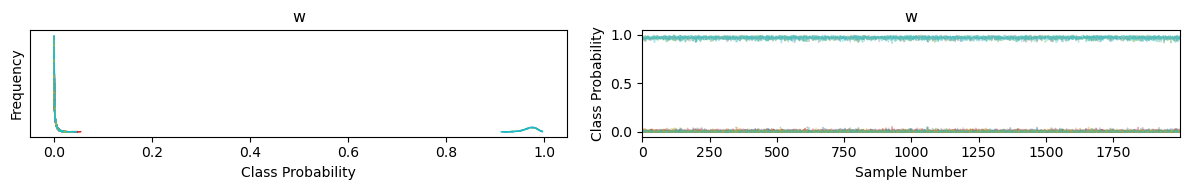

In [9]:
trace_plots(trace_1, ["w"], "t_1_a_1_b_2")

In [10]:
trace_2, summary_2, ppc_2 = generate_model(1, 2, ["w"], 10)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, theta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 56 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [obs]


Output()

In [11]:
print(summary_2[["mean", "sd", "ess_bulk", "r_hat"]].to_latex(escape=True, float_format="%.3f"))

\begin{tabular}{lrrrr}
\toprule
 & mean & sd & ess\_bulk & r\_hat \\
\midrule
w[0] & 0.038 & 0.013 & 5867.000 & 1.000 \\
w[1] & 0.193 & 0.270 & 7.000 & 1.530 \\
w[2] & 0.194 & 0.270 & 7.000 & 1.530 \\
w[3] & 0.037 & 0.013 & 5829.000 & 1.000 \\
w[4] & 0.038 & 0.013 & 6815.000 & 1.000 \\
w[5] & 0.038 & 0.013 & 6169.000 & 1.000 \\
w[6] & 0.038 & 0.013 & 5674.000 & 1.000 \\
w[7] & 0.349 & 0.312 & 6.000 & 1.730 \\
w[8] & 0.038 & 0.013 & 5519.000 & 1.000 \\
w[9] & 0.038 & 0.013 & 7443.000 & 1.000 \\
\bottomrule
\end{tabular}



In [12]:
trace_3, summary_3, ppc_3 = generate_model(1, 2, ["w"], 25)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, theta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 86 seconds.
Sampling: [obs]


Output()

In [13]:
print(summary_3[["mean", "sd", "ess_bulk", "r_hat"]].to_latex(escape=True, float_format="%.3f"))

\begin{tabular}{lrrrr}
\toprule
 & mean & sd & ess\_bulk & r\_hat \\
\midrule
w[0] & 0.101 & 0.047 & 2628.000 & 1.000 \\
w[1] & 0.100 & 0.047 & 2321.000 & 1.000 \\
w[2] & 0.099 & 0.043 & 2791.000 & 1.000 \\
w[3] & 0.100 & 0.044 & 2417.000 & 1.000 \\
w[4] & 0.102 & 0.048 & 2106.000 & 1.000 \\
w[5] & 0.099 & 0.043 & 2710.000 & 1.000 \\
w[6] & 0.101 & 0.047 & 2029.000 & 1.000 \\
w[7] & 0.101 & 0.046 & 2144.000 & 1.000 \\
w[8] & 0.098 & 0.041 & 2723.000 & 1.000 \\
w[9] & 0.100 & 0.046 & 2793.000 & 1.000 \\
\bottomrule
\end{tabular}



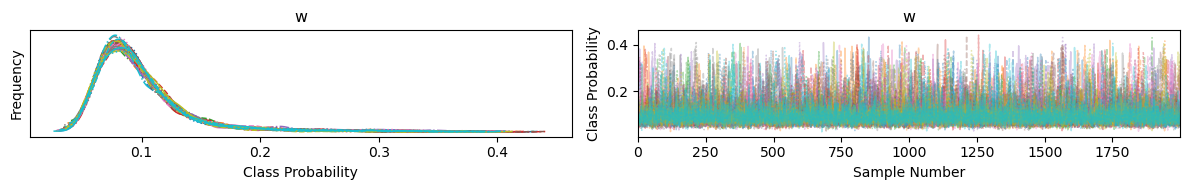

In [14]:
trace_plots(trace_3, ["w"], "t_3_a_1_b_2")

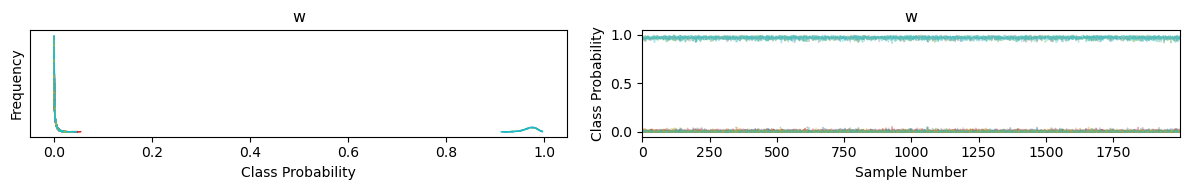

In [15]:
trace_plots(trace_1, ["w"], "a_1_b_2")

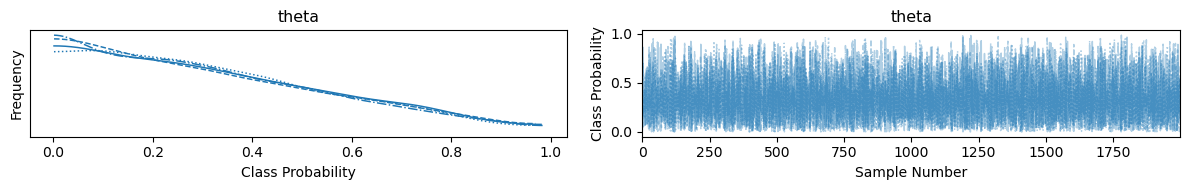

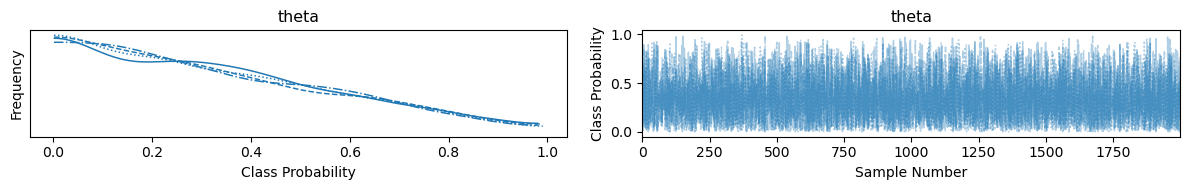

In [16]:
trace_plots(trace_1, ["theta"], "a_1_b_2_theta_off", coords={"theta_dim_0": [0], "theta_dim_1": [0]})
trace_plots(trace_1, ["theta"], "a_1_b_2_theta_on", coords={"theta_dim_0": [0], "theta_dim_1": [28]})

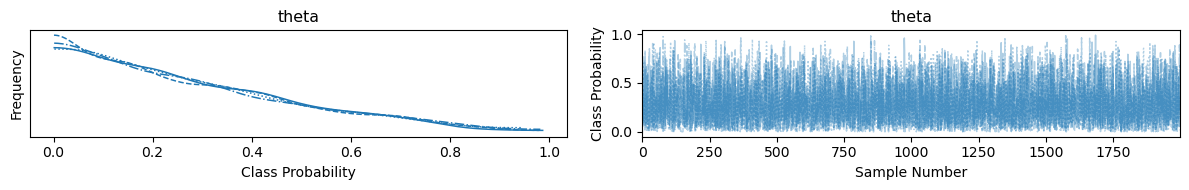

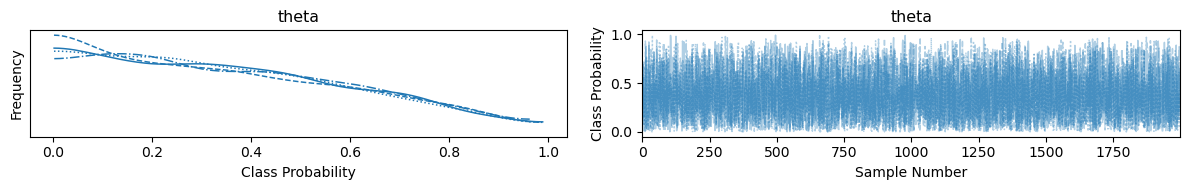

In [17]:
trace_plots(trace_2, ["theta"], "a_1_b_2_theta_off", coords={"theta_dim_0": [0], "theta_dim_1": [0]})
trace_plots(trace_2, ["theta"], "a_1_b_2_theta_on", coords={"theta_dim_0": [0], "theta_dim_1": [28]})

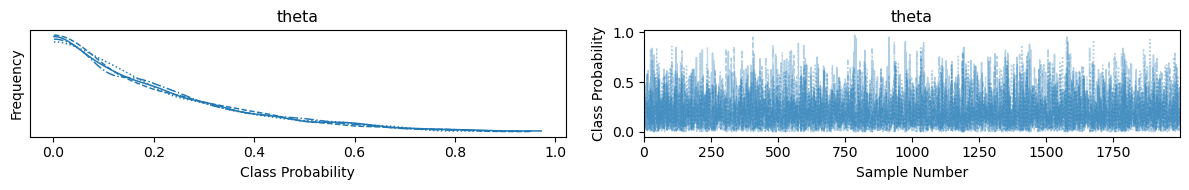

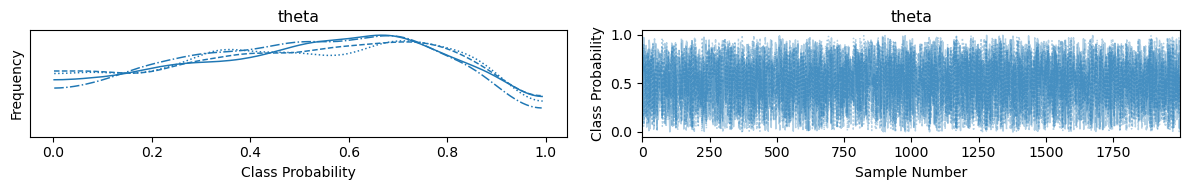

In [18]:
trace_plots(trace_3, ["theta"], "a_1_b_2_theta_off", coords={"theta_dim_0": [0], "theta_dim_1": [0]})
trace_plots(trace_3, ["theta"], "a_1_b_2_theta_on", coords={"theta_dim_0": [0], "theta_dim_1": [28]})

In [19]:
def get_trace_heatmap(trace):
    theta_posterior = az.summary(trace, var_names=["theta"])["mean"].values.reshape(K, D)
    w_posterior = az.summary(trace, var_names=["w"])["mean"].values
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for idx, ax in enumerate(axes.flat):
        ax.imshow(theta_posterior[idx].reshape(8, 8), cmap="hot", vmin=0, vmax=1)
        ax.set_title(f"Class {idx}\nw={w_posterior[idx]:.3f}")
        ax.axis("off")

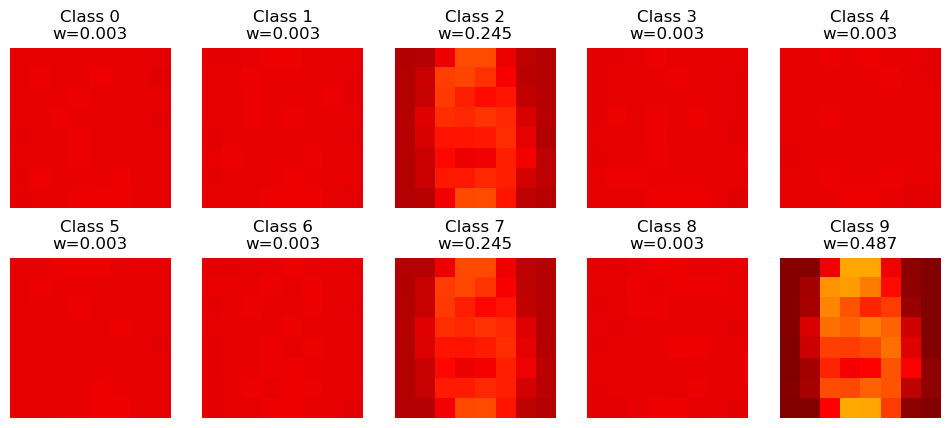

In [20]:
get_trace_heatmap(trace_1)

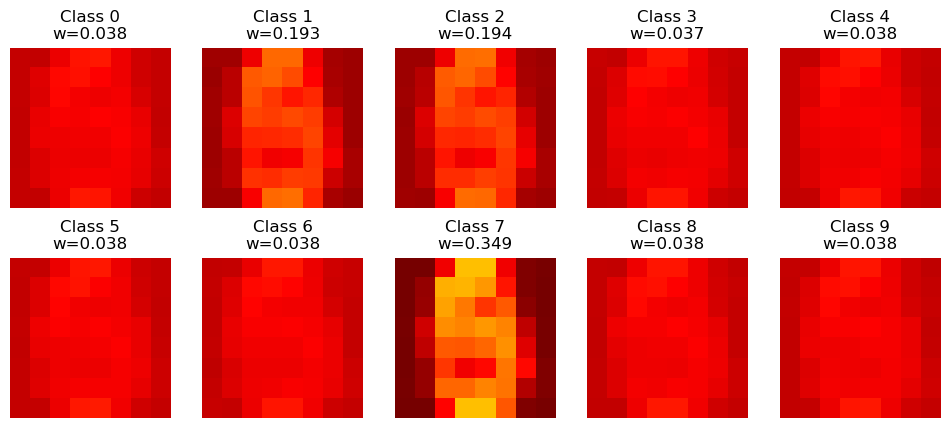

In [21]:
get_trace_heatmap(trace_2)

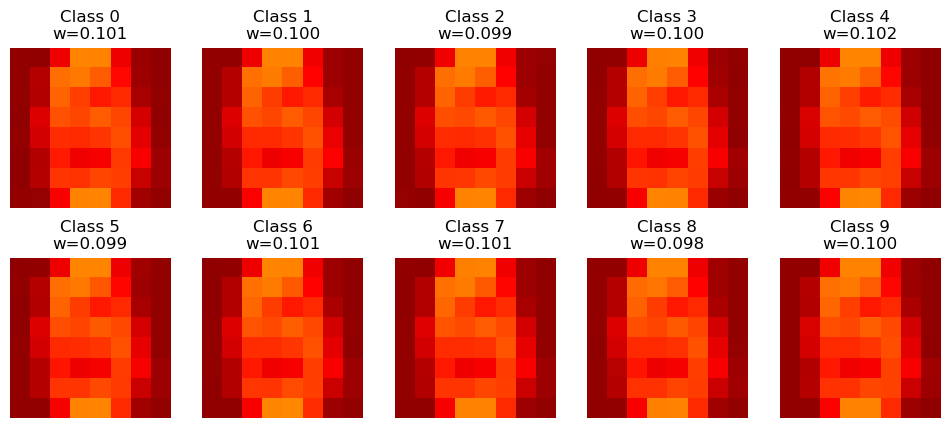

In [22]:
get_trace_heatmap(trace_3)

In [23]:
def generate_images(trace, n_images=10):
    rng = np.random.default_rng(42)
    w_samples = trace.posterior["w"].values.reshape(-1, K)
    theta_samples = trace.posterior["theta"].values.reshape(-1, K, D)
    n_posterior = w_samples.shape[0]
 
    generated = []
    for _ in range(n_images):
        idx = rng.integers(n_posterior)
        w_draw = w_samples[idx]
        theta_draw = theta_samples[idx]

        k = rng.choice(K, p=w_draw)
        pixel_probs = theta_draw[k]
        image = rng.binomial(1, pixel_probs)
        generated.append(image.reshape(8, 8))

    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for img, ax in zip(generated, axes.flat):
        ax.imshow(img, cmap="gray_r")
        ax.axis("off")
    fig.suptitle("Generated Digit Images")
    plt.tight_layout()
    plt.show()
    return generated

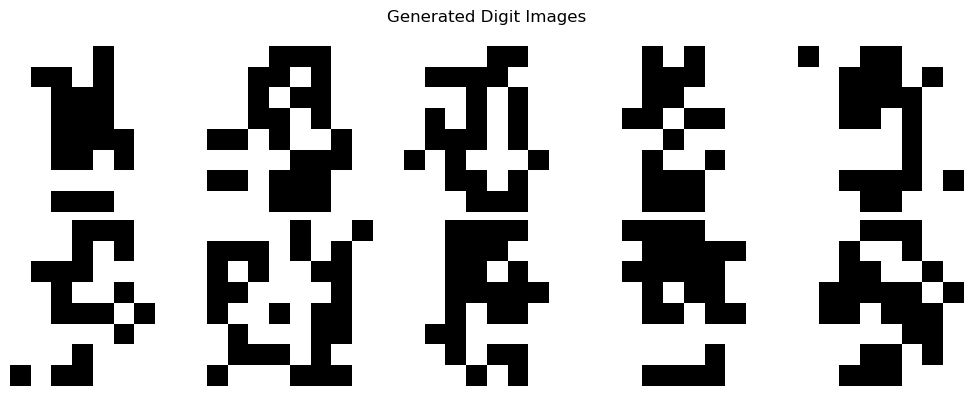

In [24]:
generated_images = generate_images(trace_1, n_images=10)


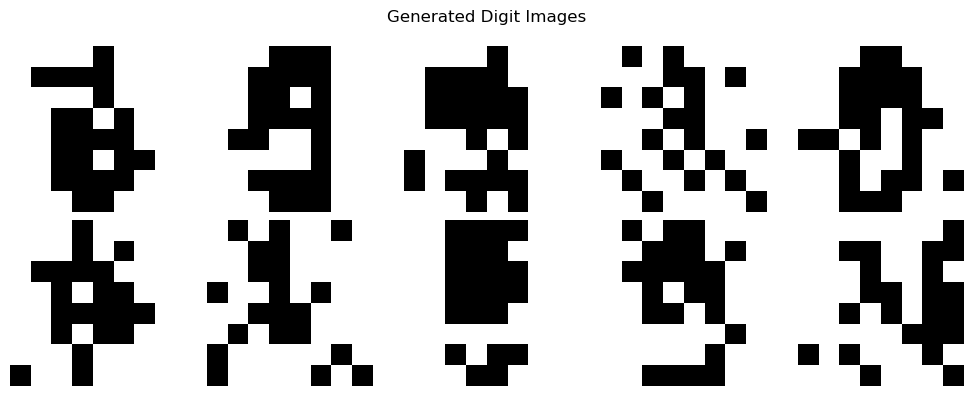

In [25]:
generated_images = generate_images(trace_2, n_images=10)

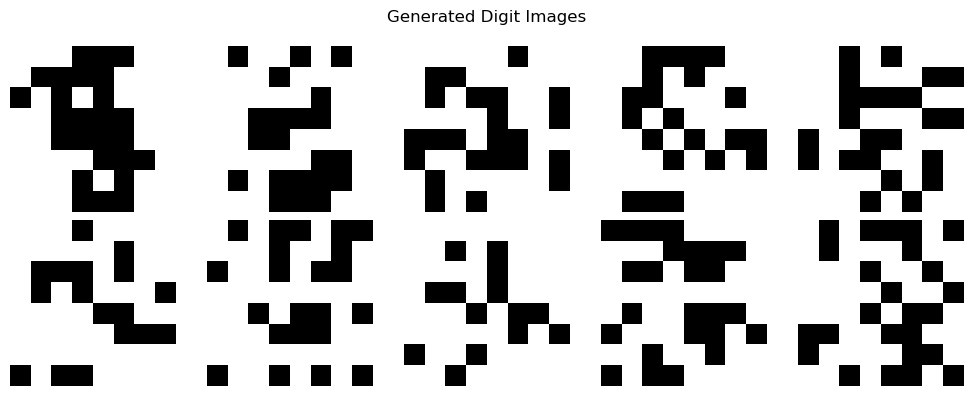

In [26]:
generated_images = generate_images(trace_3, n_images=10)


In [27]:
comparison = az.compare(
    {"Dirichlet 0.5": trace_1, "Dirichlet 10": trace_2, "Dirichlet 25": trace_3},
    scale="deviance",
)
comparison

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Dirichlet 0.5,0,1313.693555,39.531266,0.000000,1.000000e+00,36.698894,0.000000,False,deviance
Dirichlet 10,1,1425.371572,27.506931,111.678017,0.000000e+00,28.743736,10.375809,False,deviance
Dirichlet 25,2,1618.816890,20.128922,305.123335,1.419871e-10,23.385944,21.440429,False,deviance


In [28]:
print(comparison[["rank", "elpd_loo", "p_loo", "elpd_diff"]].to_latex(escape=True, float_format="%.3f"))

\begin{tabular}{lrrrr}
\toprule
 & rank & elpd\_loo & p\_loo & elpd\_diff \\
\midrule
Dirichlet 0.5 & 0 & 1313.694 & 39.531 & 0.000 \\
Dirichlet 10 & 1 & 1425.372 & 27.507 & 111.678 \\
Dirichlet 25 & 2 & 1618.817 & 20.129 & 305.123 \\
\bottomrule
\end{tabular}



In [29]:
def find_mse(ppc):
    real_pixel_means = X.mean(axis=0)
    ppc_pixel_means = ppc.posterior_predictive["obs"].mean(dim=["chain", "draw"]).values.mean(axis=0)

    mse = mean_squared_error(real_pixel_means, ppc_pixel_means)
    print(f"MSE: {mse:.4f}")
    
    fig, axes = plt.subplots(1, 1, figsize=(14, 4))
    
    axes.scatter(real_pixel_means, ppc_pixel_means)
    axes.plot([0, 1], [0, 1], "r--", label="Perfect match")
    axes.set_xlabel("Real pixel means")
    axes.set_ylabel("Posterior predictive pixel means")
    axes.set_title(f"Per-Pixel Mean (MSE = {mse:.4f})")
    axes.legend()


MSE: 0.0017


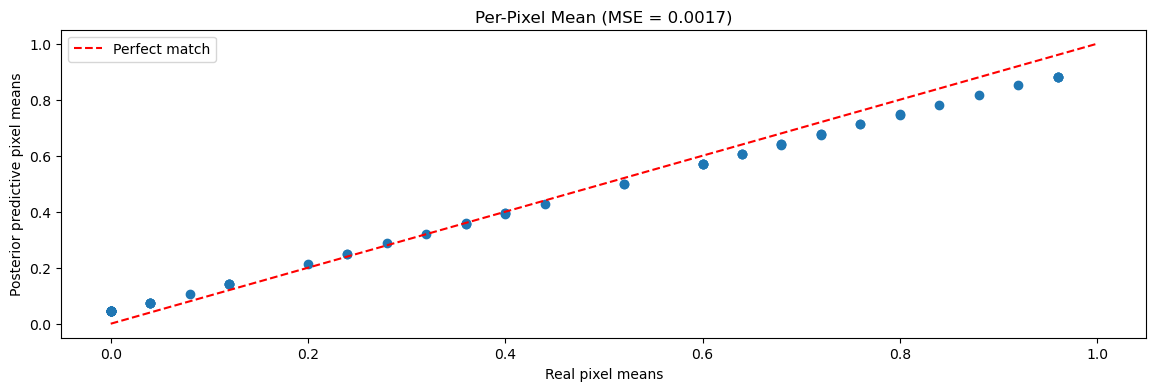

In [30]:
find_mse(ppc_1)

MSE: 0.0117


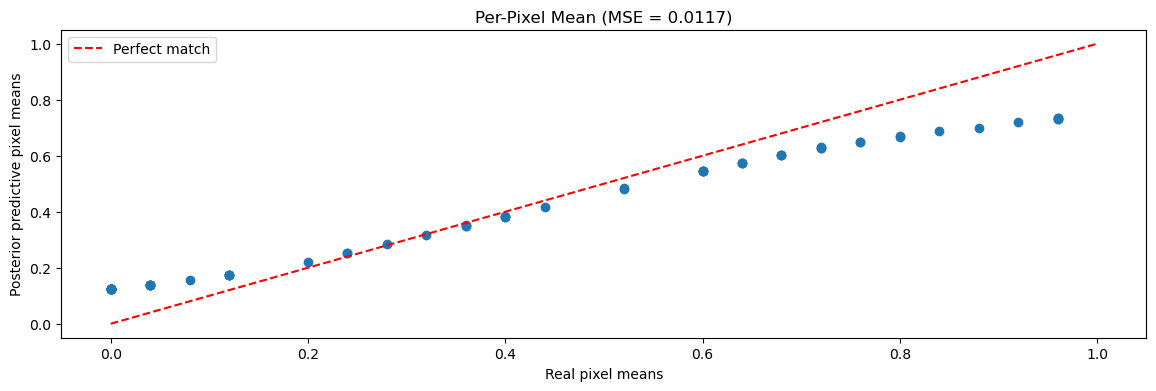

In [31]:
find_mse(ppc_2)

MSE: 0.0369


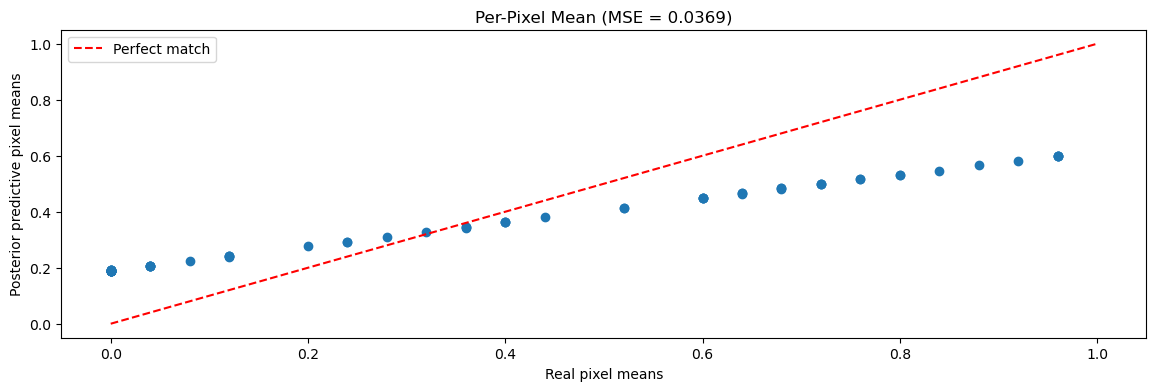

In [32]:
find_mse(ppc_3)